In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
conn = sqlite3.connect('inventory.db')
conn

In [5]:
pd.read_sql_query('select name from sqlite_master where type = "table"', conn)

,name
0,hotel_bookings
1,Hotel_data


In [7]:
#Incase the retreived  table name has extended name in it
#conn.execute("""ALTER TABLE "hotel_bookings 2" RENAME TO hotel_bookings""",conn)

In [9]:
pd.read_sql_query('select name from sqlite_master where type = "table"', conn)['name']

0    hotel_bookings
1        Hotel_data
Name: name, dtype: object

In [13]:
df = pd.read_sql('select * from hotel_bookings',con = conn)
df.head()

,index,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,0,Resort Hotel,0,342,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
1,1,Resort Hotel,0,737,2015,July,27,1,0,0,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,1/7/2015
2,2,Resort Hotel,0,7,2015,July,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
3,3,Resort Hotel,0,13,2015,July,27,1,0,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2/7/2015
4,4,Resort Hotel,0,14,2015,July,27,1,0,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,3/7/2015


In [14]:
df.set_index('index', inplace = True)

In [15]:
#Just in case renaming the index to ID is required
#df.index.name = 'ID'

In [17]:
df.shape

(119390, 32)

In [18]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [75]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,month,year
count,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,...,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897,118897.000000,118897.000000
mean,0.371347,104.312018,2016.157657,27.166674,15.800802,0.928905,2.502157,1.858390,0.104208,0.007948,...,0.087143,0.131635,0.221175,2.330774,101.958683,0.061885,0.571688,2016-07-30 07:39:51.289939968,6.334508,2016.094536
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00,1.000000,2014.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00,3.000000,2016.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00,6.000000,2016.000000
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00,9.000000,2017.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,...,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00,12.000000,2017.000000
std,0.483167,106.903570,0.707462,13.589966,8.780321,0.996217,1.900171,0.578578,0.399174,0.097381,...,0.845872,1.484678,0.652784,17.630525,48.091199,0.244173,0.792680,NaN,3.344185,0.715393


In [19]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                 

In [21]:
df['reservation_status_date']=pd.to_datetime(df['reservation_status_date'], dayfirst=True)

In [22]:
df['reservation_status_date']

index
0        2015-07-01
1        2015-07-01
2        2015-07-02
3        2015-07-02
4        2015-07-03
            ...    
119385   2017-09-06
119386   2017-09-07
119387   2017-09-07
119388   2017-09-07
119389   2017-09-07
Name: reservation_status_date, Length: 119390, dtype: datetime64[ns]

In [23]:
df.describe(include = 'object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [24]:
for col in df.describe(include  = 'object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)

hotel
['Resort Hotel' 'City Hotel']
--------------------------------------------------
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
--------------------------------------------------
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
--------------------------------------------------
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' None 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' '

In [25]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [26]:
df.drop(columns = ['company','agent'], inplace = True)

In [27]:
df.dropna(inplace=True)

In [28]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [79]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date,month,year
count,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,...,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897,118897.000000,118897.000000
mean,0.371347,104.312018,2016.157657,27.166674,15.800802,0.928905,2.502157,1.858390,0.104208,0.007948,...,0.087143,0.131635,0.221175,2.330774,101.958683,0.061885,0.571688,2016-07-30 07:39:51.289939968,6.334508,2016.094536
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00,1.000000,2014.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00,3.000000,2016.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00,6.000000,2016.000000
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00,9.000000,2017.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,...,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00,12.000000,2017.000000
std,0.483167,106.903570,0.707462,13.589966,8.780321,0.996217,1.900171,0.578578,0.399174,0.097381,...,0.845872,1.484678,0.652784,17.630525,48.091199,0.244173,0.792680,NaN,3.344185,0.715393


<Axes: ylabel='adr'>

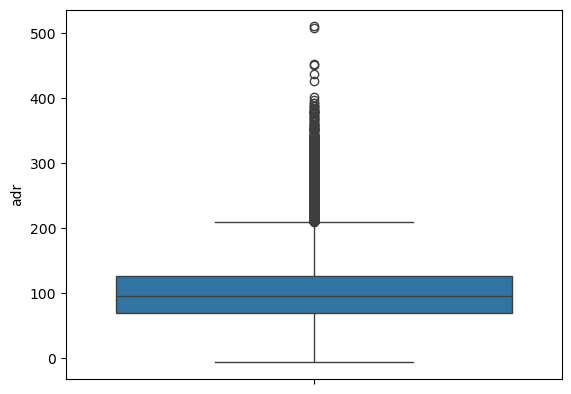

In [81]:
import seaborn as sns
sns.boxplot(df['adr'])

In [82]:
#Removing the outlier 
df = df[df['adr']<5000]

# Storing the  cleaned  data to database 

In [86]:
cursor = conn.cursor()

In [87]:
#for col in df.columns:
 #   print(df[col].head())

In [88]:
cursor.execute("""create table Hotel_data (Hotel varchar(20),
                                        is_cancelled int,
                                        lead_time int,
                                        arrival_date_year int,
                                        arrival_date_month varchar(10),
                                        arrival_date_week_number int,
                                        arrival_date_day_of_month int,
                                        stays_in_weekend_nights int,
                                        stays_in_week_nights  int, 
                                        adults int,
                                        children decimal(6,2),
                                        babies int,
                                        meal varchar(5),
                                        country varchar(5),
                                        market_segment varchar(30),
                                        distribution_channel varchar(30),
                                        is_repeated_guest int,
                                        previous_cancellations int,
                                        previous_bookings_not_canceled int,
                                        reserved_room_type varchar(5),
                                        assigned_room_type varchar(5),
                                        booking_changes int,
                                        deposit_type varchar(20),
                                        days_in_waiting_list int,
                                        customer_type varchar(30),
                                        adr decimal(5,2),
                                        required_car_parking_spaces int,
                                        total_of_special_requests int,
                                        reservation_status varchar(30),
                                        reservation_status_date date);""")
                                        
                                 
                                        

OperationalError: table Hotel_data already exists

In [ ]:
pd.read_sql('select * from hotel_data', conn)

In [ ]:
df.to_sql('Hotel_data', con = conn, if_exists = 'replace',index = False)

In [ ]:
pd.read_sql('select name from sqlite_master where type = "table"',conn)

In [ ]:
data = pd.read_sql('select * from hotel_data',conn)

# Data Analysis and  Visualizations 

In [122]:
cancelled_perc = df['is_canceled'].value_counts(normalize = True)*100
cancelled_perc

is_canceled
0    62.865337
1    37.134663
Name: proportion, dtype: float64

In [128]:
df.groupby('reservation_status')['is_canceled'].value_counts()

reservation_status  is_canceled
Canceled            1              42949
Check-Out           0              74745
No-Show             1               1203
Name: count, dtype: int64

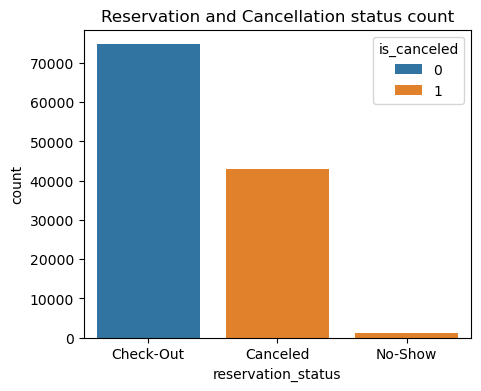

In [90]:
plt.figure(figsize = (5,4))
plt.title('Reservation and Cancellation status count')
sns.countplot(x='reservation_status',hue = 'is_canceled', data = df)
plt.show()

74745 costomers who got the reservation have checked out successfully and 42949 customers who didn't get the reservation have cancelled their booking in which 1203 have not arrived to the hotel. This indicates that there is some issue with the reservation system and the hotel customer handling.

Text(0, 0.5, 'Number of Reservations')

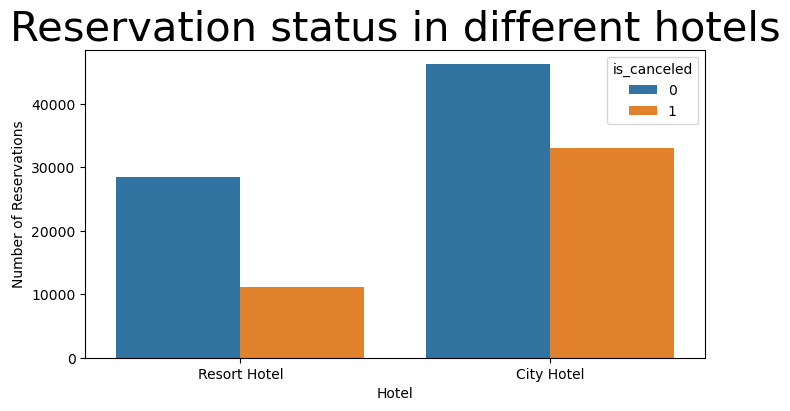

In [92]:
plt.figure(figsize = (8,4))
sns.countplot(x='hotel', data = df, hue = 'is_canceled')
plt.title('Reservation status in different hotels', size = 30)
plt.xlabel('Hotel')
plt.ylabel('Number of Reservations')

In [93]:
resort_hotel = df[df['hotel']=='Resort Hotel']
resort_hotel['is_canceled'].value_counts(normalize=True)*100

is_canceled
0    72.024952
1    27.975048
Name: proportion, dtype: float64

In [94]:
city_hotel = df[df['hotel'] == 'City Hotel']
city_hotel['is_canceled'].value_counts(normalize = True)*100

is_canceled
0    58.291825
1    41.708175
Name: proportion, dtype: float64

From the above chat we can find out that the city hotels are getting maximum reservation with higher cancellation to 41%. Where as Resort hotels get 27% cancellations.

In [116]:
df.groupby('arrival_date_year')['reservation_status'].value_counts(normalize=True)*100

arrival_date_year  reservation_status
2015               Check-Out             62.916876
                   Canceled              36.223066
                   No-Show                0.860058
2016               Check-Out             64.007513
                   Canceled              34.810575
                   No-Show                1.181912
2017               Check-Out             61.250123
                   Canceled              37.892818
                   No-Show                0.857058
Name: proportion, dtype: float64

In 2016 City hotels revenue increased to 28.51% than 2015 and again gradual decrease in 2017. Having sellable rooms per day at the rate of 88 in 2015, 104 in 2016 and 116 for 2017

In [98]:
city_hotel_check_out = city_hotel[city_hotel['reservation_status']=='Check-Out']
resort_hotel_check_out = city_hotel[city_hotel['reservation_status']=='Check-Out']

In [100]:
resort_hotel_adr = resort_hotel_check_out.groupby('reservation_status_date')['adr'].mean()
resort_hotel_adr=resort_hotel_adr.reset_index()
resort_hotel_adr

,reservation_status_date,adr
0,2015-07-03,95.111111
1,2015-07-05,74.367000
2,2015-07-06,94.000000
3,2015-07-07,66.130000
4,2015-07-08,63.777778
...,...,...
790,2017-09-03,137.172600
791,2017-09-04,116.925385
792,2017-09-05,154.000000
793,2017-09-06,93.293333


In [102]:
city_hotel_adr = city_hotel_check_out.groupby('reservation_status_date')['adr'].mean()
city_hotel_adr=city_hotel_adr.reset_index()
city_hotel_adr

,reservation_status_date,adr
0,2015-07-03,95.111111
1,2015-07-05,74.367000
2,2015-07-06,94.000000
3,2015-07-07,66.130000
4,2015-07-08,63.777778
...,...,...
790,2017-09-03,137.172600
791,2017-09-04,116.925385
792,2017-09-05,154.000000
793,2017-09-06,93.293333


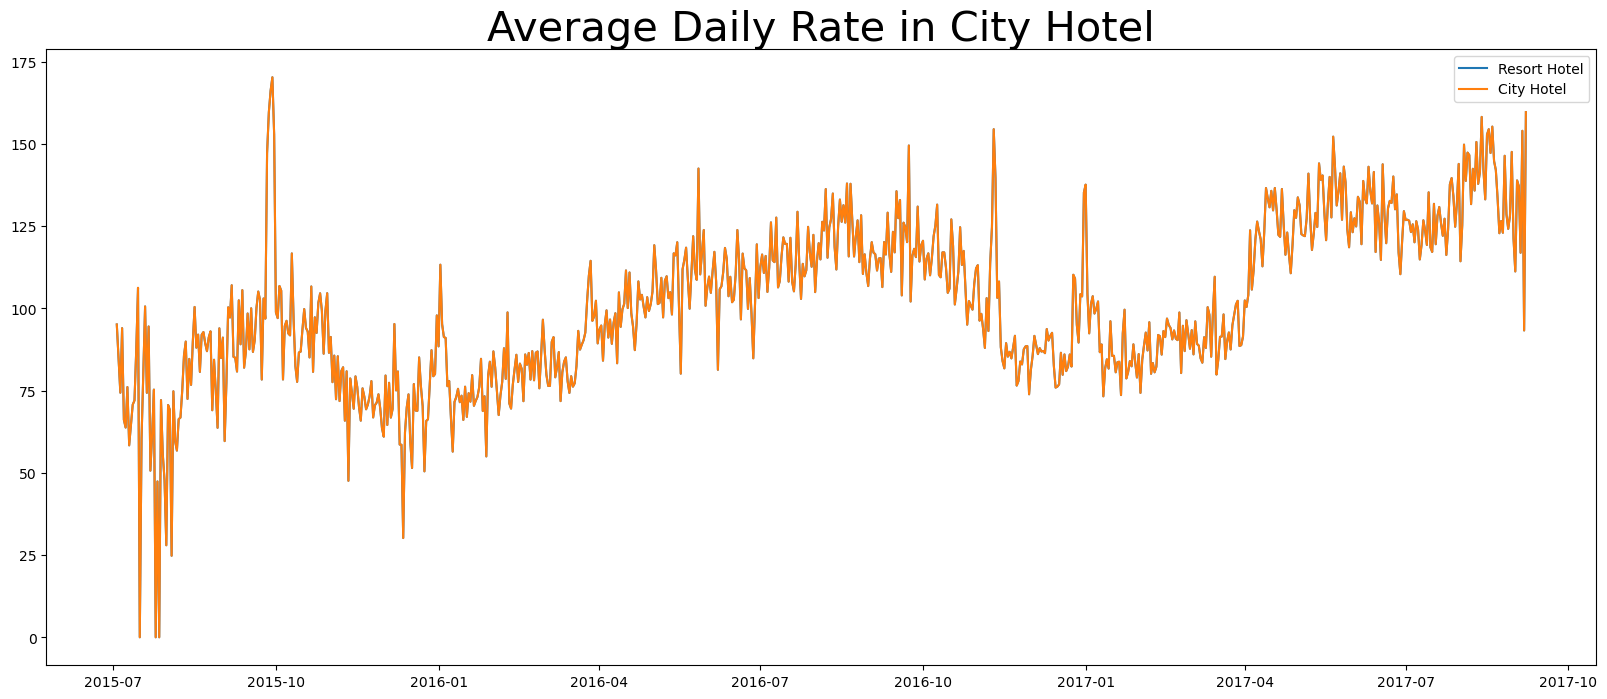

In [104]:
plt.figure(figsize = (20,8))
plt.title('Average Daily Rate in City Hotel',fontsize = 30)
plt.plot(resort_hotel_adr['reservation_status_date'], resort_hotel_adr['adr'], label = 'Resort Hotel')
plt.plot(city_hotel_adr['reservation_status_date'], city_hotel_adr['adr'], label = 'City Hotel')
plt.legend()
plt.show()

We can assume that the spikes here represents weekends pricing. Hence  the hotels have implemented  dynamic pricing stratergies.

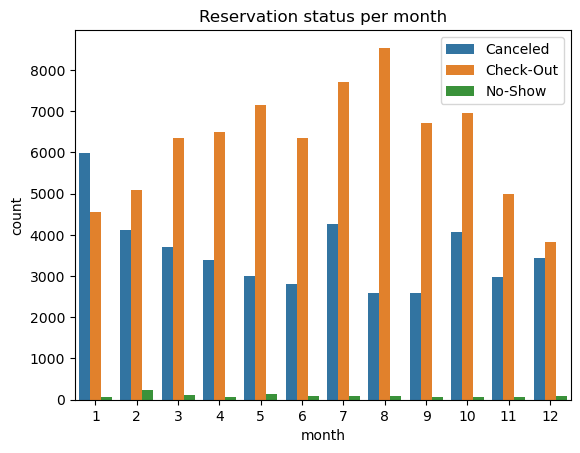

In [107]:
df['month'] = df['reservation_status_date'].dt.month
sns.countplot(x='month',hue = 'reservation_status', data = df)
plt.title('Reservation status per month')
plt.legend()
plt.show()

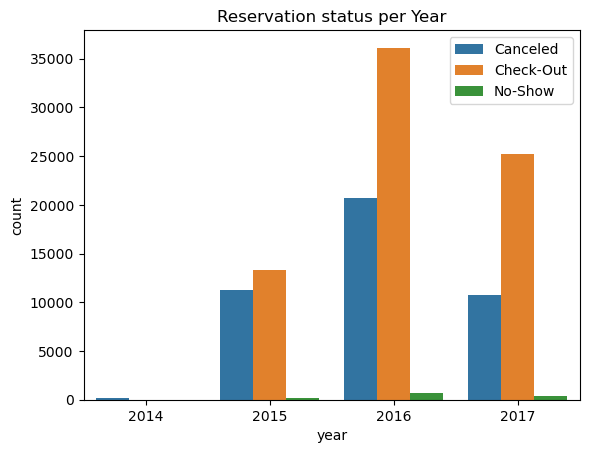

In [109]:
df['year'] = df['reservation_status_date'].dt.year
sns.countplot(x='year',hue = 'reservation_status', data = df)
plt.title('Reservation status per Year')
plt.legend()
plt.show()

In [111]:
df[df['reservation_status']=='Check-Out'].groupby('month')[['adr']].mean().reset_index()

,month,adr
0,1,76.877769
1,2,72.244064
2,3,76.736056
3,4,95.778449
4,5,104.856245
5,6,113.307748
6,7,126.395267
7,8,143.726224
8,9,111.926951
9,10,88.491070


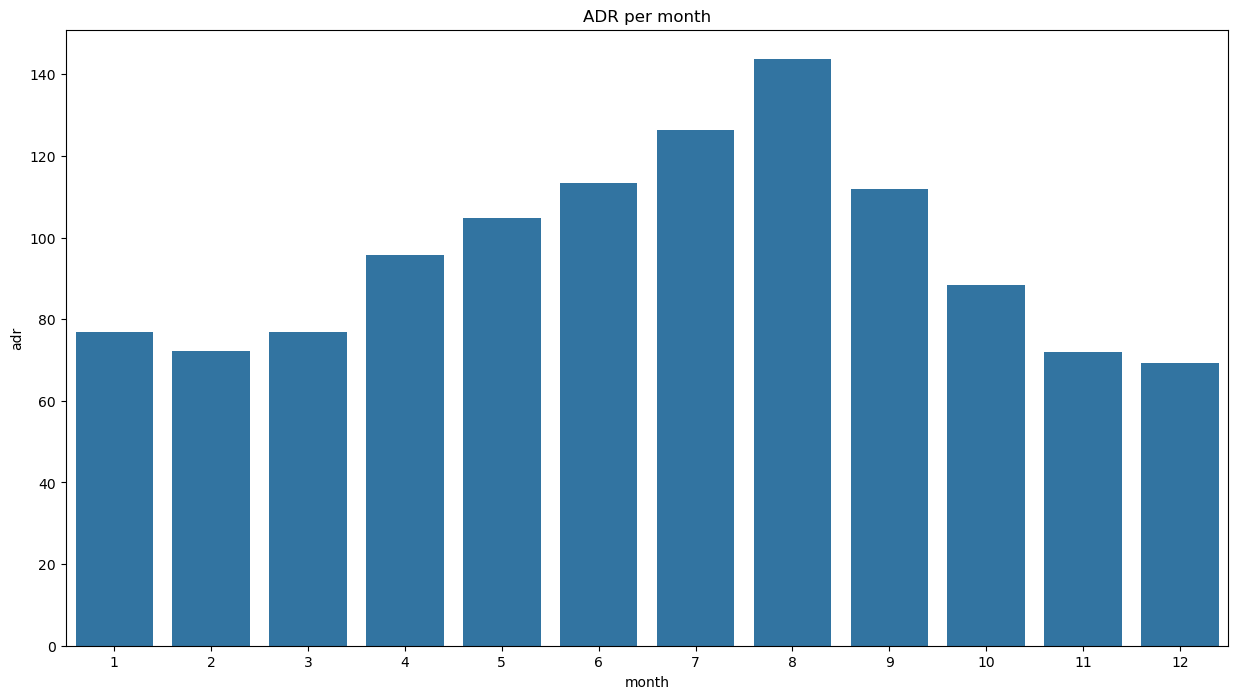

In [112]:
plt.figure(figsize = (15,8))
plt.title('ADR per month')
sns.barplot(x='month',y='adr', data = df[df['reservation_status']=='Check-Out'].groupby('month')[['adr']].mean().reset_index())
plt.show()

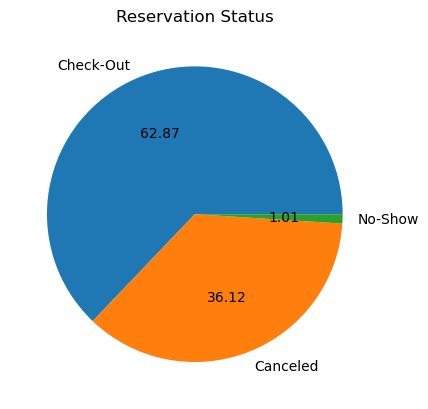

In [114]:
reservation = df['reservation_status'].value_counts(normalize = True)*100
plt.pie(reservation, autopct='%0.2f', labels = reservation.index  )
plt.title('Reservation Status')
plt.show()

In [132]:
is_cancelled = df[df['reservation_status']=='Canceled']
top_10_cancellation = is_cancelled['country'].value_counts()[:10]
top_10_cancellation

country
PRT    26751
GBR     2412
ESP     2145
FRA     1902
ITA     1315
DEU     1205
IRL      825
BRA      799
USA      472
BEL      464
Name: count, dtype: int64

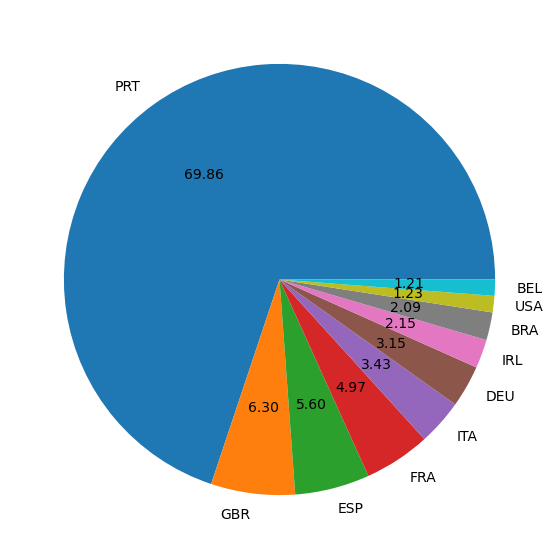

In [136]:
plt.figure(figsize = (7,7))
plt.pie(top_10_cancellation,autopct = '%0.2f', labels = top_10_cancellation.index)
plt.show()

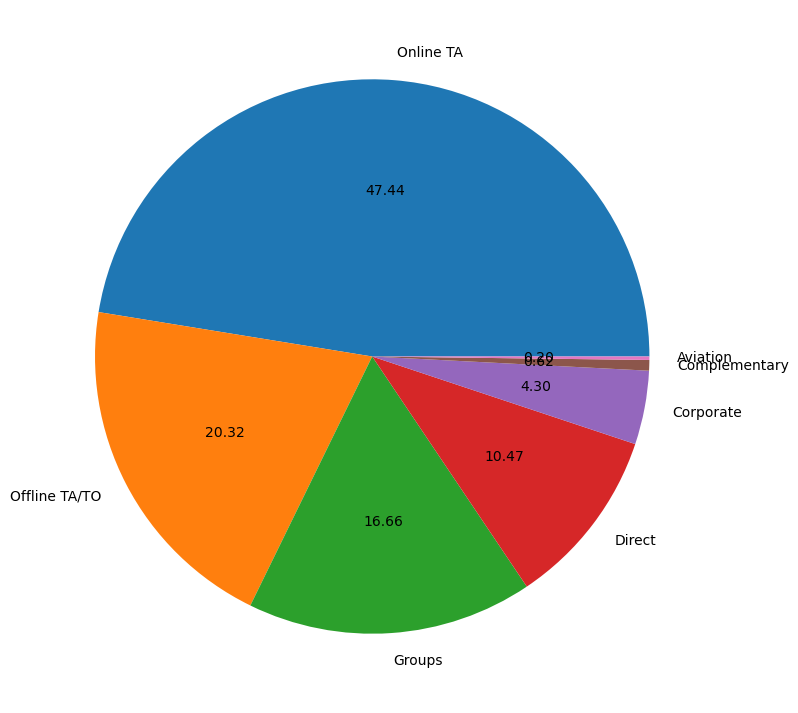

In [138]:
plt.figure(figsize = (9,9))
reserve_segment = df['market_segment'].value_counts(normalize = True)*100
plt.pie(reserve_segment,autopct='%0.02f', labels = reserve_segment.index)
plt.show()

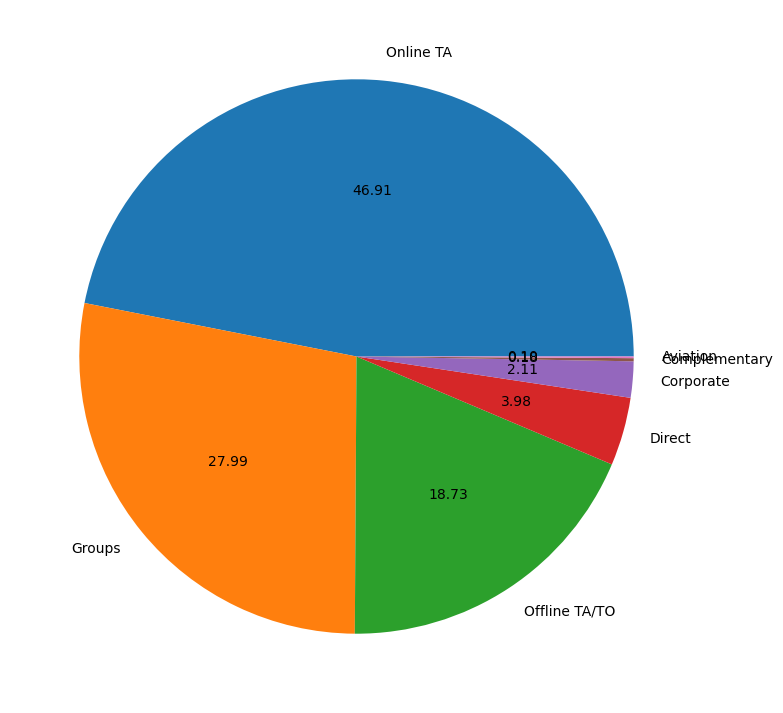

In [140]:
plt.figure(figsize = (9,9))
cancel_segment = is_cancelled['market_segment'].value_counts(normalize=True)*100
plt.pie(cancel_segment,autopct='%0.02f', labels = cancel_segment.index)
plt.show()